In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
# Load data
train_df = pd.read_csv('../datasets/train.csv')
test_df = pd.read_csv('../datasets/test.csv')
print(f"Train set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")

# Display the first 3 rows of the training set
display(train_df.head(3))

Train set shape: (24153, 58)
Test set shape: (4750, 56)


,Unnamed: 0.1,Unnamed: 0,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms
0,0,0,25436,https://www.airbnb.com/rooms/25436,20250627144659,2025-06-28,previous scrape,In the forest Sea view Two minutes to the city.,Our house is in Baby Koru. If you want village...,Clean and elegand friends . U can find everyth...,https://a0.muscache.com/pictures/b64c3ef0-2256...,105823,https://www.airbnb.com/users/show/105823,Yesim,2010-04-09,"İstanbul, Turkey","Merhabalar . Kuş sesi , akan su sesi ile uyan...",NaN,NaN,NaN,f,https://a0.muscache.com/im/pictures/user/067a8...,https://a0.muscache.com/im/pictures/user/067a8...,Beşiktaş,1.0,1.0,"['email', 'phone']",t,t,"Beşiktaş/ bebek, İstanbul, Turkey",Besiktas,NaN,41.07883,29.03863,Entire rental unit,Entire home/apt,3,NaN,1 bath,2.0,NaN,"[""Room-darkening shades"", ""Wine glasses"", ""Sel...",NaN,100,160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,1,1,0,0
1,1,1,34177,https://www.airbnb.com/rooms/34177,20250627144659,2025-07-01,city scrape,PETIT HOUSE,My petit house is located in the bosphorous an...,the neighbourhood is very calm comparing the...,https://a0.muscache.com/pictures/47356451/c288...,147330,https://www.airbnb.com/users/show/147330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Beşiktaş, İstanbul, Turkey",Besiktas,NaN,41.06681,29.04035,Entire home,Entire home/apt,3,1.0,1 bath,1.0,2.0,"[""Free dryer \u2013 In unit"", ""Extra pillows a...","1,794.00",100,365,4.69,4.69,4.88,4.88,4.81,4.69,4.81,NaN,f,5,5,0,0
2,2,2,42835,https://www.airbnb.com/rooms/42835,20250627144659,2025-06-28,previous scrape,Cozy apartment in the heart of Istanbul,Welcome to our cozy 2-bedroom apartment locate...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,187026,https://www.airbnb.com/users/show/187026,Attila,2010-07-31,"Istanbul, Turkey",I am from Istanbul/ Turkey. I will do my best ...,NaN,NaN,NaN,f,https://a0.muscache.com/im/users/187026/profil...,https://a0.muscache.com/im/users/187026/profil...,Şişli,3.0,3.0,"['email', 'phone']",t,t,NaN,Sisli,NaN,41.04303,28.98531,Entire rental unit,Entire home/apt,4,NaN,2 baths,1.0,NaN,"[""Wine glasses"", ""Laundromat nearby"", ""Cleanin...",NaN,100,730,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,3,1,2,0


In [3]:
# Display examples of the 'price' column before cleaning
print("Examples of 'price' column before cleaning:")
print(train_df['price'].head())

def clean_currency(x):
    """
    Converts currency strings (e.g., '$1,200.00') to float.
    Returns the original value if it's already a number or NaN.
    """
    if isinstance(x, str):
        # Remove dollar sign ($) and commas (,)
        clean_str = x.replace('$', '').replace(',', '').strip()
        # Return NaN if the resulting string is empty
        if clean_str == '':
            return np.nan
        return float(clean_str)
    return x

# Apply the cleaning function to the 'price' column
train_df['price'] = train_df['price'].apply(clean_currency)

print("\n------------------------------------------------")
print("Statistics of 'price' column after cleaning:")
print(train_df['price'].describe())
print("\n------------------------------------------------")
print(train_df['price'].head())

Examples of 'price' column before cleaning:
0         NaN
1    1,794.00
2         NaN
3    2,331.00
4         NaN
Name: price, dtype: object

------------------------------------------------
Statistics of 'price' column after cleaning:
count    2.080400e+04
mean     4.523767e+03
std      4.016376e+04
min      8.000000e+01
25%      1.580750e+03
50%      2.493000e+03
75%      3.956000e+03
max      4.250147e+06
Name: price, dtype: float64

------------------------------------------------
0       NaN
1    1794.0
2       NaN
3    2331.0
4       NaN
Name: price, dtype: float64


In [4]:
# 1. Check for missing (NaN) prices
missing_price_count = train_df['price'].isnull().sum()
print(f"Number of rows with missing (NaN) price: {missing_price_count}")

# 2. Check for zero or negative prices (Potential data error)
zero_price_count = (train_df['price'] <= 0).sum()
print(f"Number of rows with price <= 0: {zero_price_count}")

# Cleaning Operation:
# Drop rows where price is NaN OR price is <= 0
initial_count = len(train_df)
train_df = train_df.dropna(subset=['price'])
train_df = train_df[train_df['price'] > 0]
final_count = len(train_df)

print(f"\nTotal rows removed: {initial_count - final_count}")
print(f"Remaining clean rows for modeling: {final_count}")
print("\n------------------------------------------------")
print("Examples of 'price' column after cleaning:")
print(train_df['price'].head())

Number of rows with missing (NaN) price: 3349
Number of rows with price <= 0: 0

Total rows removed: 3349
Remaining clean rows for modeling: 20804

------------------------------------------------
Examples of 'price' column after cleaning:
1    1794.0
3    2331.0
5    4984.0
6    1668.0
7    1507.0
Name: price, dtype: float64


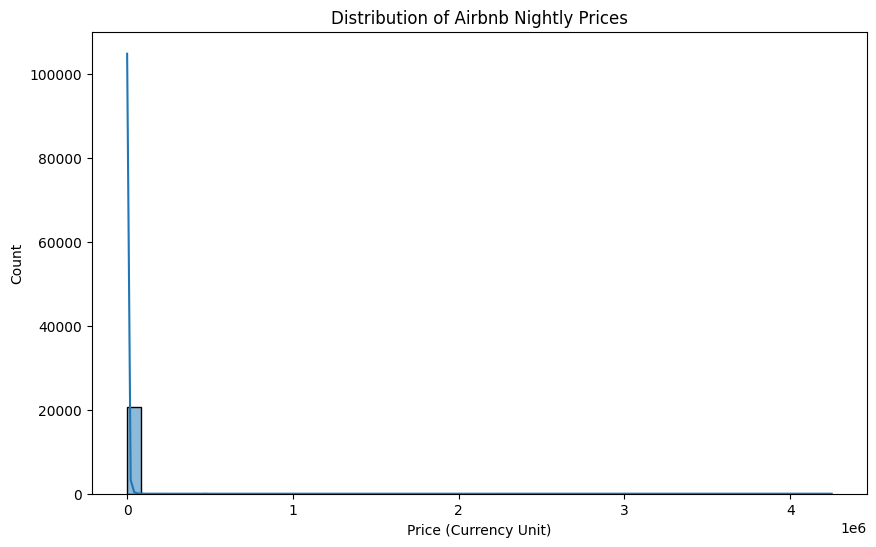

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(train_df['price'], bins=50, kde=True)
plt.title("Distribution of Airbnb Nightly Prices")
plt.xlabel("Price (Currency Unit)")
plt.ylabel("Count")
plt.show()

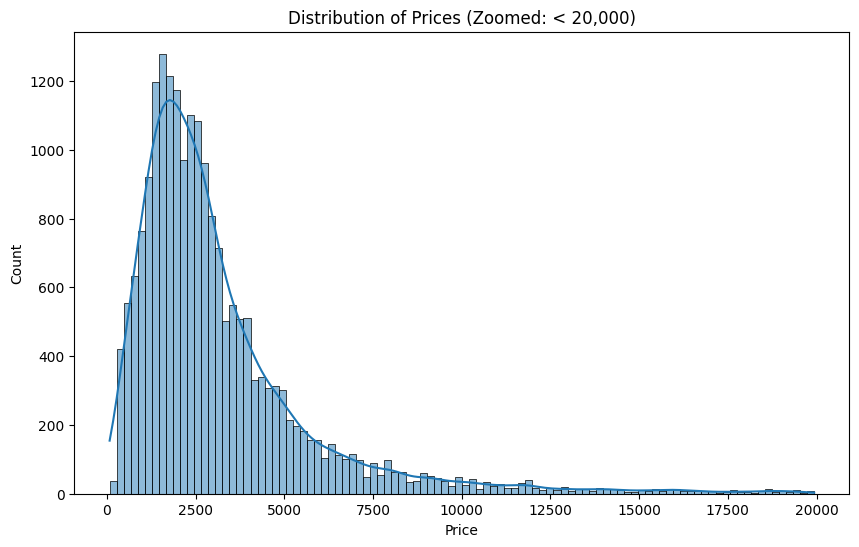

In [6]:
subset_df = train_df[train_df['price'] < 20000]

plt.figure(figsize=(10, 6))
sns.histplot(subset_df['price'], bins=100, kde=True)
plt.title("Distribution of Prices (Zoomed: < 20,000)")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

In [ ]:
# Save the cleaned data to a new CSV file
output_path = '../datasets/interim/cleaned_train.csv'
train_df.to_csv(output_path, index=False)